In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 엑셀 파일 읽기 = 추후 통합본 필요
df = pd.read_excel("../results/ResultListByTestModel_yjh.xlsx")

# 조건 필터링 (AUC > 0.82) 필요한 컬럼 추출
plot_data = df.loc[df["AUC"] > 0.5, ["NO", "Model_Name", "AUC", "F1_Score", "Recall"]]


In [10]:
# 변환 대상 컬럼 지정
cols = ["AUC", "F1_Score", "Recall"]

# 숫자로 변환 (변환 불가능한 값은 NaN 처리)
plot_data[cols] = plot_data[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

plot_data.info()
print(plot_data)

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NO          22 non-null     int64  
 1   Model_Name  22 non-null     object 
 2   AUC         22 non-null     float64
 3   F1_Score    22 non-null     float64
 4   Recall      22 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.0+ KB
    NO           Model_Name     AUC  F1_Score  Recall
0    1              XGBoost  0.8421    0.0099  0.0050
1    2  Logistic Regression  0.6216    0.0000  0.0000
2    3              XGBoost  0.8528    0.0099  0.0050
3    4  Logistic Regression  0.6024    0.0000  0.0000
4    5              XGBoost  0.8417    0.0196  0.0100
5    6  Logistic Regression  0.6229    0.0000  0.0000
6    7              XGBoost  0.8516    0.0132  0.0066
7    8  Logistic Regression  0.6423    0.0766  0.1096
8    9              XGBoost  0.8522    0.0066  0.0033
9   10  Logist

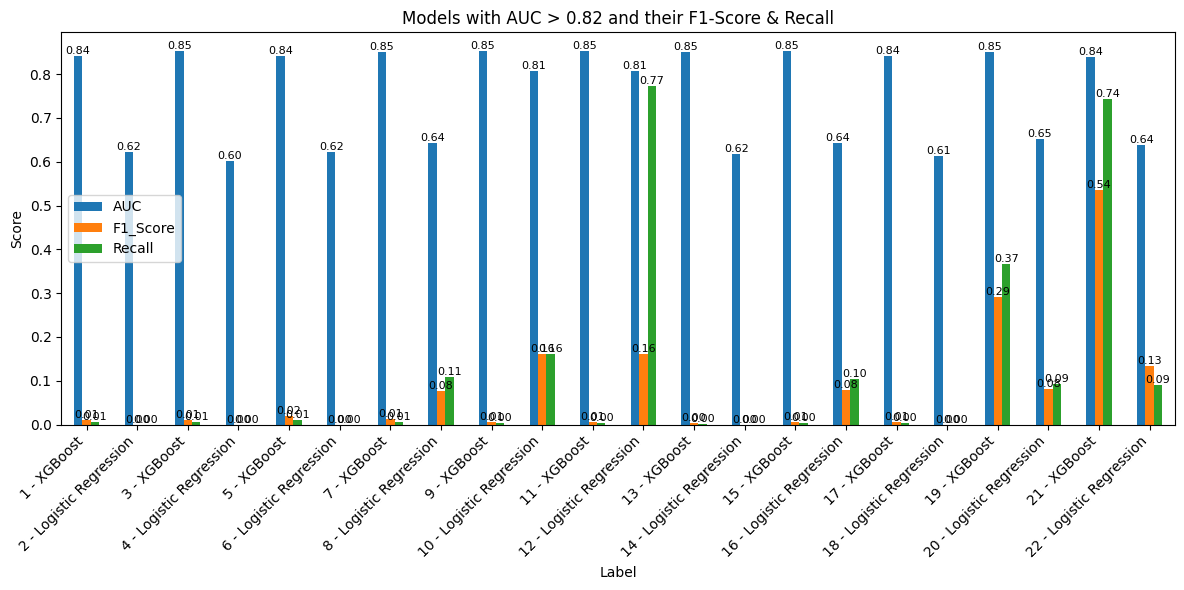

In [11]:

# No + Model Name 결합해서 새로운 라벨 생성
plot_data["Label"] = plot_data["NO"].astype(str) + " - " + plot_data["Model_Name"]

# Label을 인덱스로 설정
ax = plot_data.set_index("Label")[["AUC", "F1_Score", "Recall"]].plot(kind="bar", figsize=(12,6))

plt.title("Models with AUC > 0.82 and their F1-Score & Recall")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="best")

# 각 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
